In [27]:
import os
from PIL import Image
import glob

def concatenate_images_vertically():
    """
    读取当前目录中的所有PNG文件，并将它们从上到下垂直拼接成一个图片
    """
    # 获取当前目录中所有的PNG文件
    png_files = glob.glob("*.png")
    
    if not png_files:
        print("当前目录中没有找到PNG文件")
        return
    
    # 按文件名排序，确保拼接顺序一致
    png_files.sort()
    
    print(f"找到 {len(png_files)} 个PNG文件:")
    for file in png_files:
        print(f"  - {file}")
    
    # 打开所有图片
    images = []
    for file in png_files:
        try:
            img = Image.open(file)
            images.append(img)
            print(f"成功加载: {file} (尺寸: {img.size})")
        except Exception as e:
            print(f"无法加载 {file}: {e}")
    
    if not images:
        print("没有成功加载任何图片")
        return
    
    # 计算拼接后图片的宽度和高度
    # 宽度取所有图片中的最大宽度
    max_width = max(img.width for img in images)
    total_height = sum(img.height for img in images)
    
    print(f"拼接后图片尺寸: {max_width} x {total_height}")
    
    # 创建一个新的空白图片
    result_image = Image.new('RGBA', (max_width, total_height), (255, 255, 255, 0))
    
    # 逐个粘贴图片
    current_y = 0
    for img in images:
        # 如果图片宽度小于最大宽度，居中放置
        x_offset = (max_width - img.width) // 2
        result_image.paste(img, (x_offset, current_y))
        current_y += img.height
    
    # 保存拼接后的图片
    # output_filename = "concatenated_image.png"
    # result_image.save(output_filename)
    # print(f"拼接完成！输出文件: {output_filename}")
    return result_image
    
    # 关闭所有打开的图片
    for img in images:
        img.close()

result_image = concatenate_images_vertically()

找到 3 个PNG文件:
  - dimmed00.png
  - dimmed28.png
  - dimmed45.png
成功加载: dimmed00.png (尺寸: (1971, 492))
成功加载: dimmed28.png (尺寸: (1971, 492))
成功加载: dimmed45.png (尺寸: (1971, 492))
拼接后图片尺寸: 1971 x 1476


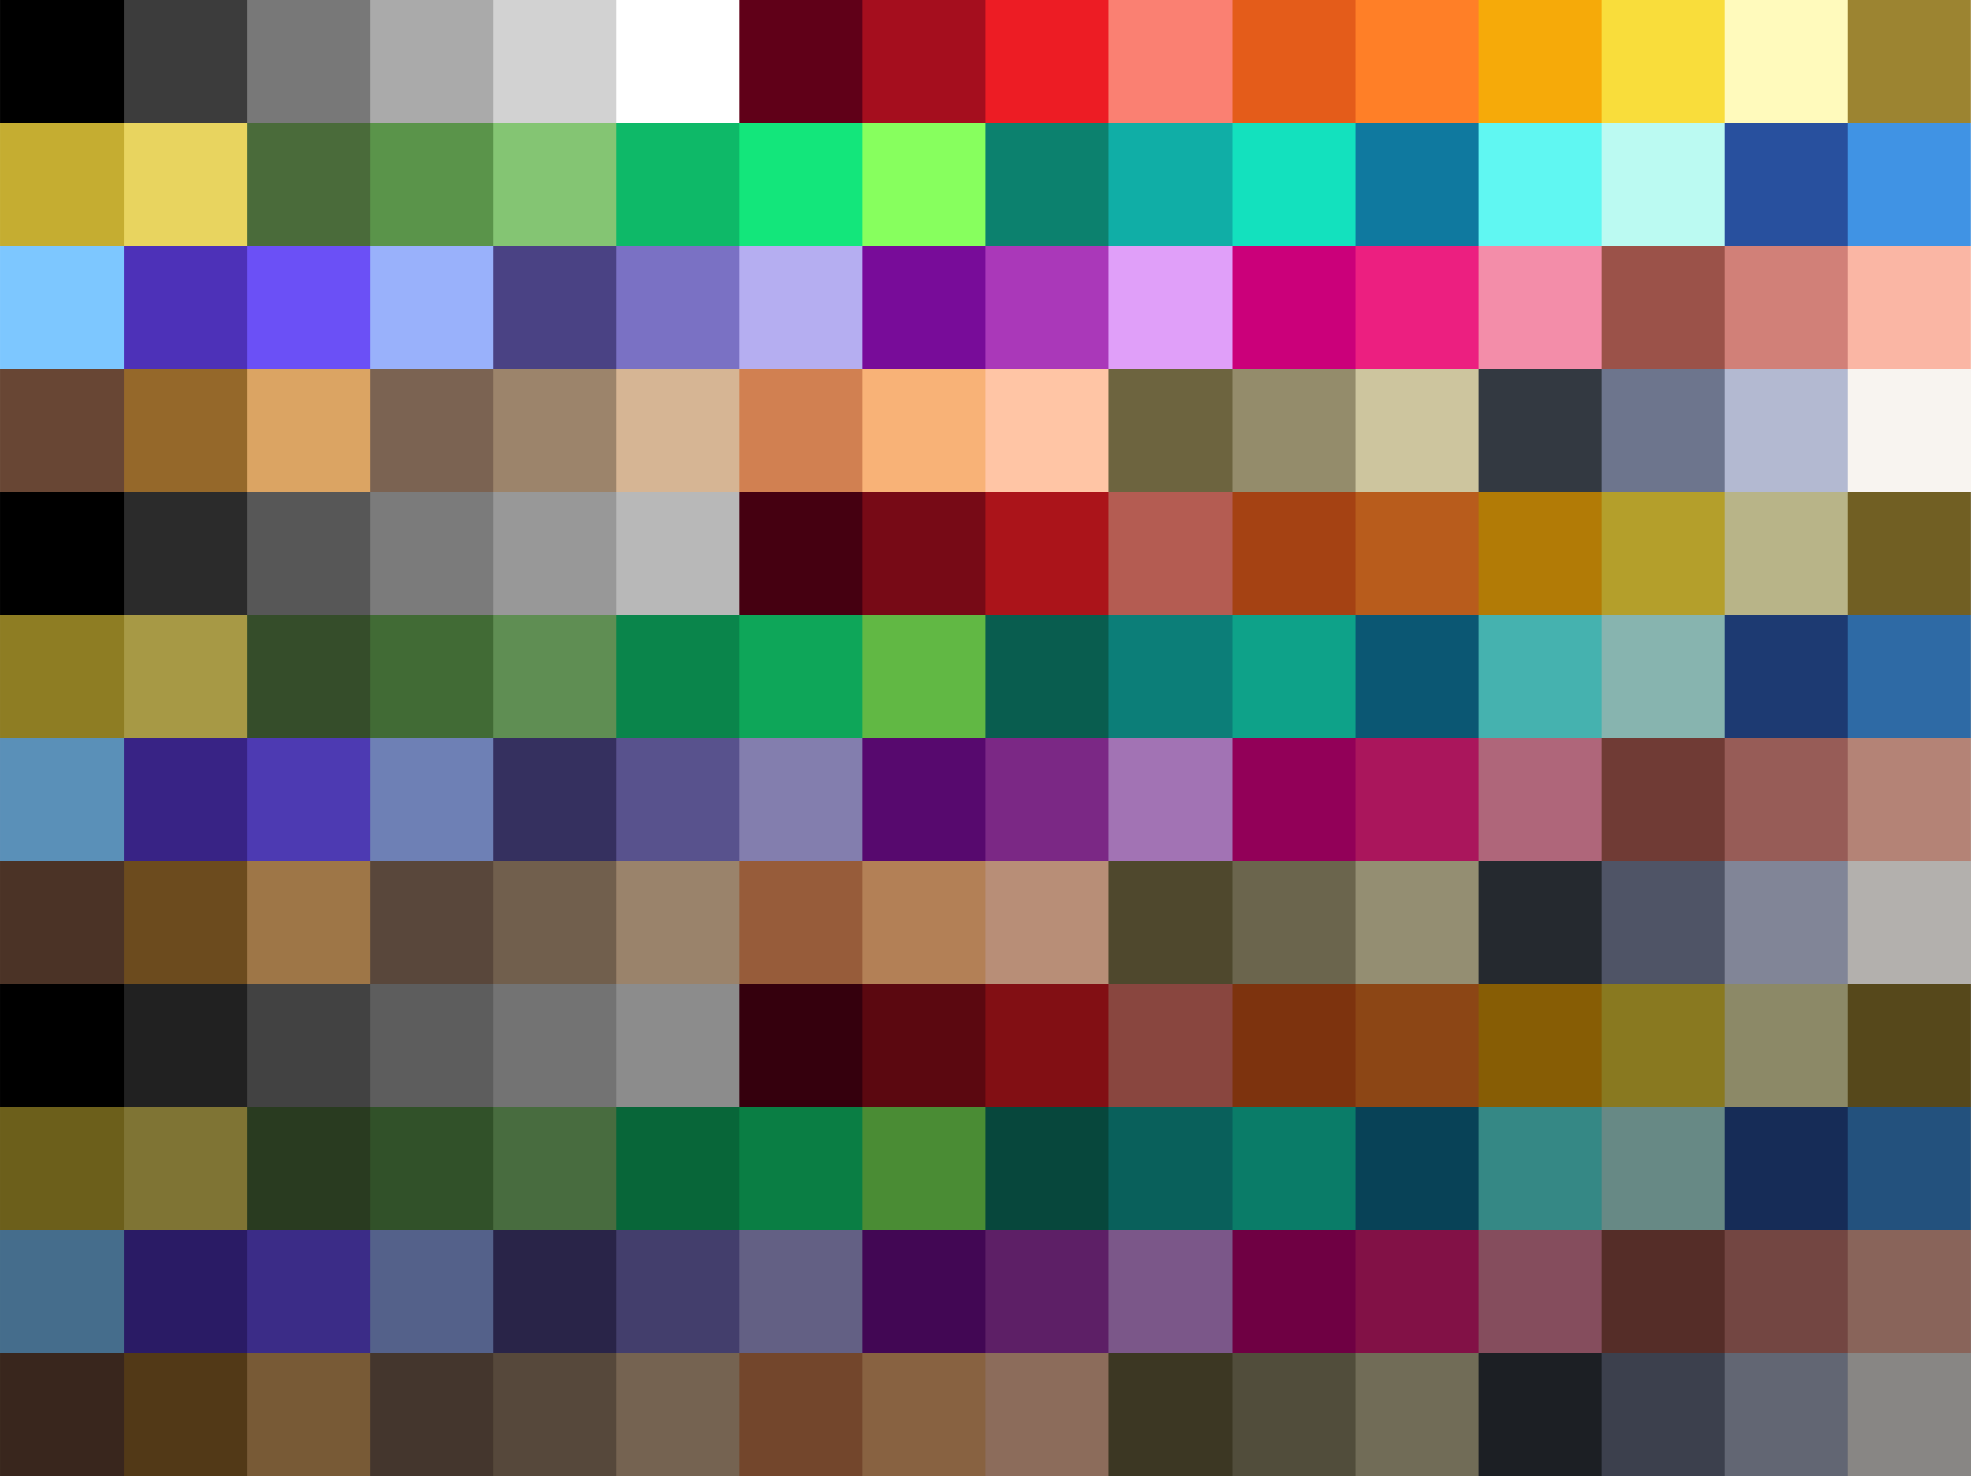

In [8]:
result_image

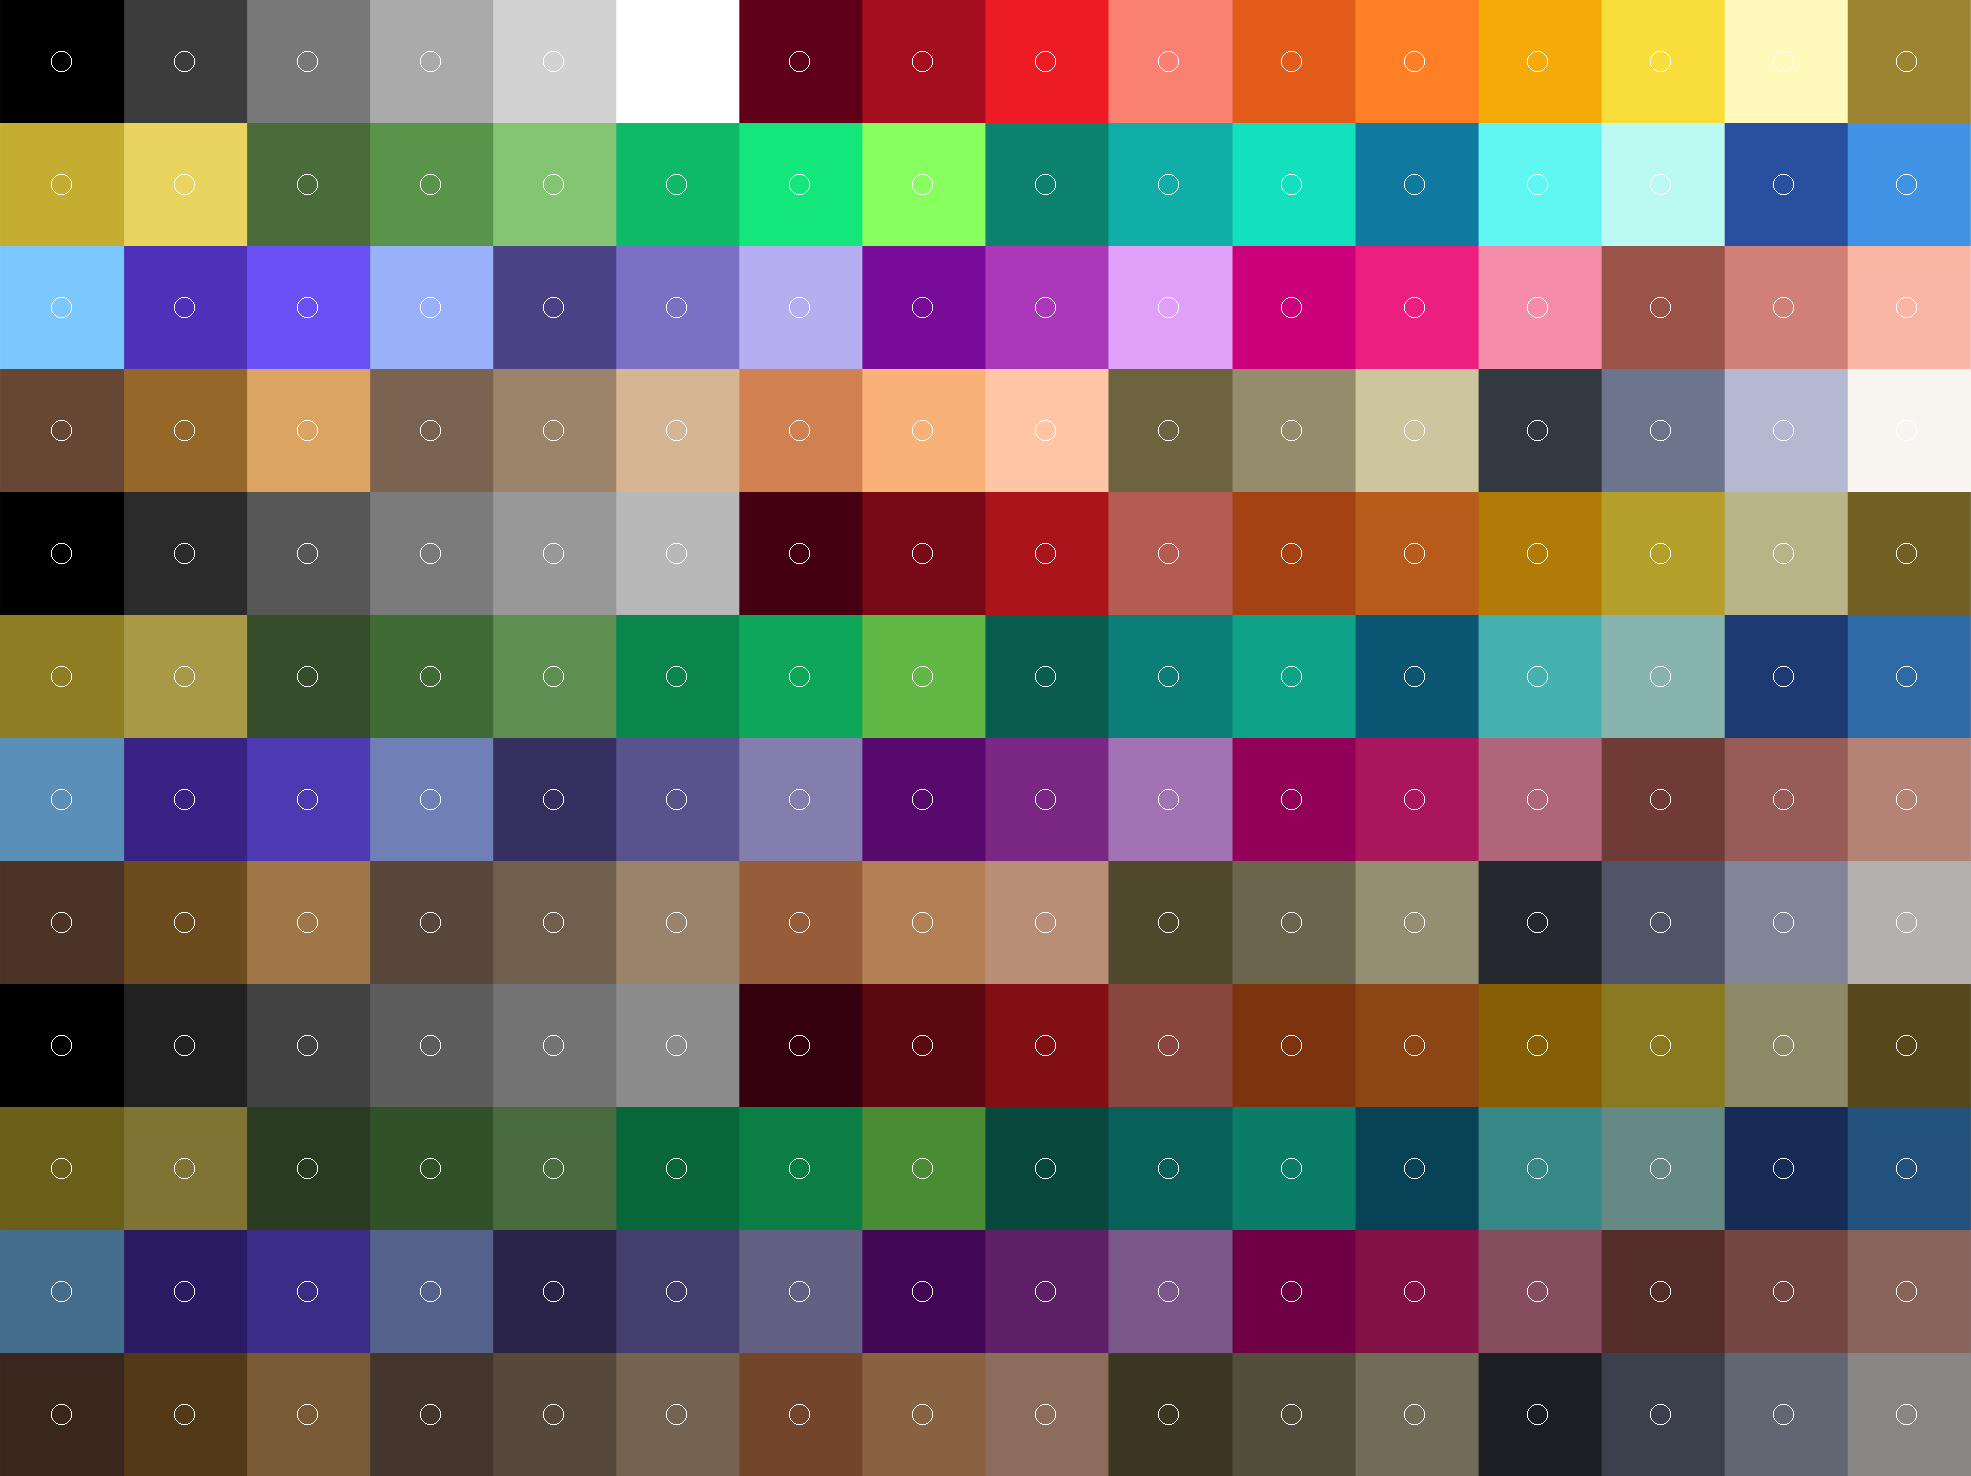

In [28]:
from PIL import ImageDraw

length = 123
marker_size = 10
draw = ImageDraw.Draw(result_image)

log = dict()

for i in range(3):
    log[i] = []
    for xi in range(16):
        for yi in range(4):
            coord = (int(length/2 + length*xi), int(length/2 + length*yi + length*4*i))
            coord1 = (int(length/2 + length*xi) - marker_size, int(length/2 + length*yi + length*4*i) - marker_size)
            coord2 = (int(length/2 + length*xi) + marker_size, int(length/2 + length*yi + length*4*i) + marker_size)
            draw.ellipse([coord1, coord2])
            log[i].append(result_image.getpixel(coord))
        
result_image

In [30]:
targets = [0, 2, 4, 8, 16, 32]
for t in targets:
    print('-'*16)
    for i in range(3):
        print(log[i][t])

----------------
(0, 0, 0, 255)
(0, 0, 0, 255)
(0, 0, 0, 255)
----------------
(125, 199, 255, 255)
(90, 144, 184, 255)
(69, 109, 140, 255)
----------------
(60, 60, 60, 255)
(43, 43, 43, 255)
(33, 33, 33, 255)
----------------
(120, 120, 120, 255)
(87, 87, 87, 255)
(66, 66, 66, 255)
----------------
(210, 210, 210, 255)
(152, 152, 152, 255)
(115, 115, 115, 255)
----------------
(237, 28, 36, 255)
(171, 20, 26, 255)
(130, 15, 20, 255)


结论：
插件使用的是简单的线性缩放，`color_dimmed = color * (1-dim_val)`

In [41]:
with open('colors.txt', 'w') as file:
    for i in range(64):
        color = log[0][i]
        for j in range(3):
            file.write(f"{str(hex(color[j])).removeprefix('0x'):0>2}")
        file.write('\n')